In [187]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt

### Step 1. Upload yaml file data

In [19]:
with open('data1/books.yaml', 'r', encoding='utf-8') as file:
    data = yaml.safe_load(file)

In [20]:
books_df = pd.DataFrame(data)
print(books_df)

       :id                                 :title  \
0    19199           The Yellow Meads of Asphodel   
1    19398                  From Here to Eternity   
2    19483                        Eyeless in Gaza   
3    19506                          Precious Bane   
4    19570                            City of God   
..     ...                                    ...   
748  19246  Eternal Sunshine of the Spotless Mind   
749  19452  Command & Conquer: Tiberium Alliances   
750  18843                           Ice Climbers   
751  19494                     Mad Max: Fury Road   
752  19152                             Just Cause   

                                              :author  \
0                                       Carolyne West   
1    Rep. Heath Stiedemann, Gino Welch, Haydee Larson   
2                                      Vannessa Price   
3                                     Miss Yong Wyman   
4                                        Travis Moore   
..                   

### Step 2. Data preparation for yaml file

#### Step 2.1. Columns cleaning

In [21]:
books_df.columns = books_df.columns.str.replace(":", "", regex=False)

In [22]:
books_df.head()

,id,title,author,genre,publisher,year
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001
2,19483,Eyeless in Gaza,Vannessa Price,Biography/Autobiography,Pavilion Books,1886
3,19506,Precious Bane,Miss Yong Wyman,Realistic fiction,New English Library,2021
4,19570,City of God,Travis Moore,Suspense/Thriller,Bellevue Literary Press,1847


#### Step 2.2. Type conversion in the <i>title</i> and <i>author</i> columns

In [25]:
books_df["title"] = books_df["title"].astype("string")
books_df["author"] = books_df["author"].astype("string")

#### Step 2.3. Cleaning and conversion <i>year</i> column

In [27]:
mask = pd.to_numeric(books_df["year"], errors="coerce").isna() & books_df["year"].notna()
books_df.loc[mask, "year"].unique()

array(['-', '\t', 'NULL', ' '], dtype=object)

In [28]:
books_df.loc[mask, ["title", "year"]]

,title,year
154,Postern of Fate,-
268,Castle Crashers,\t
343,Falling into You,\t
453,The Dark Knight,NULL
511,Inception,
604,A Darkling Plain,\t
676,Surprised by Joy,NULL


In [29]:
books_df["year"] = books_df["year"].astype("string").str.strip()

In [30]:
books_df["year"] = pd.to_numeric(books_df["year"], errors="coerce").astype("Int16")

#### Step 2.4. Type conversion in the <i>publisher</i> column

In [34]:
books_df["publisher"].nunique()

247

In [35]:
books_df["publisher"].nunique(dropna=False)

248

In [36]:
books_df["publisher"].value_counts(dropna=False)

publisher
Target Books                        9
George Routledge & Sons             9
Dalkey Archive Press                8
NavPress                            7
Blackie and Son Limited             7
                                   ..
Carlton Publishing Group            1
Cambridge University Press          1
Chronicle Books                     1
Carnegie Mellon University Press    1
Papadakis Publisher                 1
Name: count, Length: 248, dtype: int64

In [43]:
books_df["publisher"] = (
    books_df["publisher"]
    .astype("string")
    .str.strip()
    .replace(["", "NULL", "-"], pd.NA)
    .astype("category")
)

In [44]:
books_df["publisher"].dtype

CategoricalDtype(categories=['Academic Press', 'Ace Books', 'Addison-Wesley',
                  'Adis International', 'Airiti Press', 'Allen Ltd',
                  'André Deutsch', 'Anova Books', 'Anvil Press Poetry',
                  'Applewood Books',
                  ...
                  'Verso Books', 'Victor Gollancz Ltd', 'Viking Press',
                  'Vintage Books', 'Vintage Books at Random House',
                  'Virgin Publishing', 'Voyager Books', 'Zed Books',
                  'Ziff Davis Media', 'Zondervan'],
, ordered=False, categories_dtype=string)

In [46]:
books_df["publisher"].nunique(dropna=False)

244

#### Step 2.5. Type conversion in the <i>genre</i> column

In [54]:
books_df["genre"].nunique(dropna=False)

30

In [55]:
books_df["genre"].value_counts(dropna=False).tail(30)

genre
Short story                40
Historical fiction         34
Fantasy                    34
Folklore                   32
Fairy tale                 31
Fiction narrative          31
Tall tale                  30
Crime/Detective            29
Fable                      29
Humor                      28
Realistic fiction          27
Suspense/Thriller          27
Metafiction                27
Classic                    26
Legend                     25
Horror                     25
Biography/Autobiography    24
Narrative nonfiction       24
Mystery                    24
Fiction in verse           24
Mythopoeia                 23
Textbook                   23
Science fiction            22
Speech                     21
Fanfiction                 20
Essay                      16
Mythology                  16
Reference book             15
Western                    15
Comic/Graphic Novel        11
Name: count, dtype: int64

In [56]:
books_df["genre"] = books_df["genre"].astype("category")

In [57]:
books_df["genre"].dtype

CategoricalDtype(categories=['Biography/Autobiography', 'Classic', 'Comic/Graphic Novel',
                  'Crime/Detective', 'Essay', 'Fable', 'Fairy tale',
                  'Fanfiction', 'Fantasy', 'Fiction in verse',
                  'Fiction narrative', 'Folklore', 'Historical fiction',
                  'Horror', 'Humor', 'Legend', 'Metafiction', 'Mystery',
                  'Mythology', 'Mythopoeia', 'Narrative nonfiction',
                  'Realistic fiction', 'Reference book', 'Science fiction',
                  'Short story', 'Speech', 'Suspense/Thriller', 'Tall tale',
                  'Textbook', 'Western'],
, ordered=False, categories_dtype=str)

#### Step 2.5. Checking data 

In [59]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         753 non-null    int64   
 1   title      753 non-null    string  
 2   author     753 non-null    string  
 3   genre      753 non-null    category
 4   publisher  740 non-null    category
 5   year       744 non-null    Int16   
dtypes: Int16(1), category(2), int64(1), string(2)
memory usage: 32.4 KB


### Step 3. Upload parquet file

In [72]:
orders_df = pd.read_parquet("data1/orders.parquet", engine="fastparquet")

In [73]:
orders_df.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,None
1,66343,47049,19403,1,€50¢50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599"
2,72606,46685,19500,1,USD 45.99,"22:13:35,2025-07-02",
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,
4,72691,45311,19388,1,52.25 $,"08:48:47 A.M.,28-August-2024",None


In [75]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11237 entries, 0 to 11236
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          11237 non-null  int64 
 1   user_id     11237 non-null  int64 
 2   book_id     11237 non-null  int64 
 3   quantity    11237 non-null  int32 
 4   unit_price  11237 non-null  object
 5   timestamp   11237 non-null  object
 6   shipping    8427 non-null   object
dtypes: int32(1), int64(3), object(3)
memory usage: 570.8+ KB


### Step 4. Data preparation for <i>parquet</i> file

#### Step 4.1. Type conversion in the <i>timestamp</i> column

In [80]:
clean_ts = (
    orders_df["timestamp"]
    .astype("string")
    .str.strip()
    .str.replace("A.M.", "AM", regex=False)
    .str.replace("P.M.", "PM", regex=False)
    .str.replace(";", " ", regex=False)
    .str.replace(",", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

orders_df["timestamp_parsed"] = pd.to_datetime(
    clean_ts,
    format="mixed",
    errors="coerce",
    dayfirst=True
)

In [82]:
orders_df["date"] = orders_df["timestamp_parsed"].dt.normalize()

In [84]:
bad_mask = orders_df["timestamp_parsed"].isna() & orders_df["timestamp"].notna()
orders_df.loc[bad_mask, "timestamp"].unique()

array([], dtype=object)

In [85]:
orders_df.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,timestamp_parsed,date
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,None,2024-01-10 10:38:08,2024-01-10
1,66343,47049,19403,1,€50¢50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599",2024-10-19 10:14:00,2024-10-19
2,72606,46685,19500,1,USD 45.99,"22:13:35,2025-07-02",,2025-02-07 22:13:35,2025-02-07
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,,2025-10-20 16:25:20,2025-10-20
4,72691,45311,19388,1,52.25 $,"08:48:47 A.M.,28-August-2024",None,2024-08-28 08:48:47,2024-08-28


#### Step 4.2. Type conversion in the <i>unit price</i> column

In [97]:
price_raw = (
    orders_df["unit_price"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", "", regex=True)
)

orders_df["unit_price_currency"] = (
    price_raw
    .str.extract(r"(USD|EUR|\$|€)", expand=False)
    .replace({"$": "USD", "€": "EUR"})
)

amount_str = (
    price_raw
    .str.replace(r"^(\d+)(\$|€)(\d+)¢$", r"\1.\3", regex=True)
    .str.replace(r"^(USD|EUR|\$|€)(\d+)¢(\d+)$", r"\2.\3", regex=True)
    .str.replace(r"USD|EUR|\$|€", "", regex=True)
    .str.replace("¢", ".", regex=False)
    .str.replace(",", ".", regex=False)
    .str.replace(r"[^\d.]", "", regex=True)
)

orders_df["unit_price_value"] = pd.to_numeric(amount_str, errors="coerce")

In [96]:
orders_df[["unit_price", "unit_price_currency", "unit_price_value"]].head(20)

,unit_price,unit_price_currency,unit_price_value
0,27.00$,USD,27.0
1,€50¢50,EUR,50.5
2,USD 45.99,USD,45.99
3,€ 71.00,EUR,71.0
4,52.25 $,USD,52.25
5,22$75¢,USD,22.75
6,35 USD,USD,35.0
7,33.00 USD,USD,33.0
8,44.75USD,USD,44.75
9,49.0USD,USD,49.0


In [95]:
orders_df[["unit_price", "unit_price_currency", "unit_price_value"]].tail(20)

,unit_price,unit_price_currency,unit_price_value
11217,€64¢50,EUR,64.5
11218,61.5$,USD,61.5
11219,14.75$,USD,14.75
11220,32.0USD,USD,32.0
11221,USD51.99,USD,51.99
11222,USD22.25,USD,22.25
11223,51.99$,USD,51.99
11224,21.25EUR,EUR,21.25
11225,52.50$,USD,52.5
11226,€ 53.5,EUR,53.5


In [98]:
bad_mask = orders_df["unit_price_value"].isna() | orders_df["unit_price_currency"].isna()
orders_df.loc[bad_mask, "unit_price"].drop_duplicates()

Series([], Name: unit_price, dtype: object)

#### Step 4.3. Currency conversion in the <i>unit price</i> column

In [102]:
mask = (orders_df["unit_price_currency"] == "EUR")

orders_df.loc[mask, "unit_price_value"] = (
    orders_df.loc[mask, "unit_price_value"] * 1.2
).round(2)

orders_df.loc[mask, "unit_price_currency"] = "USD"

In [103]:
orders_df["unit_price_currency"].value_counts(dropna=False)

unit_price_currency
USD    11237
Name: count, dtype: Int64

In [105]:
orders_df[["unit_price_currency", "unit_price_value"]].tail(20)

,unit_price_currency,unit_price_value
11217,USD,77.4
11218,USD,61.5
11219,USD,14.75
11220,USD,32.0
11221,USD,51.99
11222,USD,22.25
11223,USD,51.99
11224,USD,25.5
11225,USD,52.5
11226,USD,64.2


#### Step 4.4. Adding a <i>paid price</i> column

In [116]:
orders_df["paid_price"] = orders_df["quantity"] * orders_df["unit_price_value"]

#### Step 4.5. Checking data

In [119]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11237 entries, 0 to 11236
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   11237 non-null  int64         
 1   user_id              11237 non-null  int64         
 2   book_id              11237 non-null  int64         
 3   quantity             11237 non-null  int32         
 4   shipping             8427 non-null   object        
 5   date                 11237 non-null  datetime64[us]
 6   unit_price_currency  11237 non-null  string        
 7   unit_price_value     11237 non-null  Float64       
 8   paid_price           11237 non-null  Float64       
dtypes: Float64(2), datetime64[us](1), int32(1), int64(3), object(1), string(1)
memory usage: 768.3+ KB


In [121]:
orders_df.head()

,id,user_id,book_id,quantity,shipping,date,unit_price_currency,unit_price_value,paid_price
0,71389,47288,18976,2,None,2024-01-10,USD,27.0,54.0
1,66343,47049,19403,1,"4940 Arnoldo Keys, West Arnette, KS 77599",2024-10-19,USD,60.6,60.6
2,72606,46685,19500,1,,2025-02-07,USD,45.99,45.99
3,68462,45336,18992,1,,2025-10-20,USD,85.2,85.2
4,72691,45311,19388,1,None,2024-08-28,USD,52.25,52.25


### Step 5. Upload csv file

In [124]:
users_df = pd.read_csv("data1/users.csv")

In [131]:
users_df.head(5)

,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",(462) 385-4294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",913.466.4487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",(801) 970-3335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",895.829.5417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",(113) 784-3410,minh@hettinger.example


In [126]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3293 entries, 0 to 3292
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       3293 non-null   int64
 1   name     3293 non-null   str  
 2   address  3177 non-null   str  
 3   phone    3293 non-null   str  
 4   email    3293 non-null   str  
dtypes: int64(1), str(4)
memory usage: 128.8 KB


### Step 6. Data preparation for csv file

#### Step 6.1. Formatting <i>phone</i> column

In [132]:
phones = users_df["phone"].astype("string").str.replace(r"\D", "", regex=True)

users_df["phone_clean"] = phones
users_df["phone_formatted"] = phones.str.replace(
    r"^(\d{3})(\d{3})(\d{4})$",
    r"(\1) \2-\3",
    regex=True
)

In [135]:
# To check "broken" phones
phones = users_df["phone"].astype("string").str.replace(r"\D", "", regex=True)
bad_mask = phones.str.len() != 10
users_df.loc[bad_mask, "phone"].drop_duplicates()

Series([], Name: phone, dtype: str)

#### Step 6.2. Checking data

In [146]:
users_df.head()

,id,name,address,email,phone
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",mckinley.rowe@harber.example,(462) 385-4294
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",francisco@murray-cronin.test,(913) 466-4487
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",marguerita@wuckert.test,(801) 970-3335
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",annabelle@hessel.test,(895) 829-5417
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",minh@hettinger.example,(113) 784-3410


In [147]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3293 entries, 0 to 3292
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       3293 non-null   int64 
 1   name     3293 non-null   str   
 2   address  3177 non-null   str   
 3   email    3293 non-null   str   
 4   phone    3293 non-null   string
dtypes: int64(1), str(3), string(1)
memory usage: 128.8 KB


### Step 7. Task 1 - top 5 days by revenue

In [153]:
daily_revenue_df = (
    orders_df
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "daily_revenue"})
    .sort_values("daily_revenue", ascending=False)
)

top_5_days = daily_revenue_df.head(5)
print(top_5_days)

          date  daily_revenue
296 2024-11-14       3911.974
364 2025-01-21       3509.696
263 2024-10-12       3499.118
368 2025-01-25       3423.408
291 2024-11-09       3283.918


### Step 8. Task 2 - unique users number

In [163]:
df = users_df.copy()

for col in ["name", "address", "phone"]:
    df[col] = df[col].astype("string").str.strip().str.lower()

for col in ["name", "address", "phone"]:
    df[col] = df[col].replace(["", "nan", "none"], pd.NA)

parent = list(range(len(df)))

In [164]:
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

In [165]:
doubles = [
    ["name", "address"],
    ["name", "phone"],
    ["address", "phone"],
]

In [166]:
for cols in doubles:
    temp = df.reset_index().dropna(subset=cols)
    grouped = temp.groupby(cols)["index"].apply(list)

    for ids in grouped:
        first = ids[0]
        for other in ids[1:]:
            union(first, other)

real_unique_users = len({find(i) for i in range(len(df))})
print(real_unique_users)

3115


### Step 9. Task 3 - unique sets of authors

In [170]:
author_sets = (
    books_df["author"]
    .astype("string")
    .str.lower()
    .str.split(",")
    .apply(lambda authors: tuple(sorted(a.strip() for a in authors if a.strip())))
)

unique_author_sets_count = author_sets.nunique()
print(unique_author_sets_count)

325


### Step 10. Task 4 - the most popular author

In [172]:
books_tmp = books_df.copy()

books_tmp["author_set"] = (
    books_tmp["author"]
    .astype("string")
    .str.lower()
    .str.split(",")
    .apply(lambda authors: tuple(sorted(a.strip() for a in authors if a.strip())))
)

author_set_sales = (
    orders_df
    .merge(books_tmp[["id", "author_set"]], left_on="book_id", right_on="id", how="left")
    .groupby("author_set", as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "sold_book_count"})
    .sort_values("sold_book_count", ascending=False)
)

print(author_set_sales.head(1))

         author_set  sold_book_count
38  (arlinda huel,)              201


### Step 11. Task 5 - top customers

In [176]:
users_df["customer_group"] = [find(i) for i in range(len(df))]

In [178]:
user_group_map = users_df[["id", "customer_group"]]

customer_spending = (
    orders_df
    .merge(user_group_map, left_on="user_id", right_on="id", how="left")
    .groupby("customer_group", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "total_spending"})
    .sort_values("total_spending", ascending=False)
)

top_group = customer_spending.iloc[0]["customer_group"]
top_total_spending = customer_spending.iloc[0]["total_spending"]

top_customer_user_ids = users_df.loc[
    users_df["customer_group"] == top_group, "id"
].tolist()

print("Top customer group:", top_group)
print("Total spending:", top_total_spending)
print("All related user_id values:", top_customer_user_ids)

Top customer group: 373.0
Total spending: 1386.76
All related user_id values: [45062, 46955, 44850]


In [181]:
top_customer_records = users_df.loc[
    users_df["customer_group"] == top_group,
    ["id", "name", "address", "email", "phone"]
]

print(top_customer_records)

         id                name  \
373   45062  Rev. Johnson Olson   
1327  46955       Yukiko Becker   
2228  44850       Yukiko Becker   

                                                address  \
373   Apt. 245 5042 Annette Islands, South Andrevill...   
1327  Apt. 245 5042 Annette Islands, South Andrevill...   
2228  Apt. 245 5042 Annette Islands, South Andrevill...   

                                email           phone  
373   jorge@hartmann-medhurst.example  (149) 407-0465  
1327  jorge@hartmann-medhurst.example  (443) 893-1024  
2228  jorge@hartmann-medhurst.example  (149) 407-0465  


### Step 12. Task 6 - line chart of daily revenue

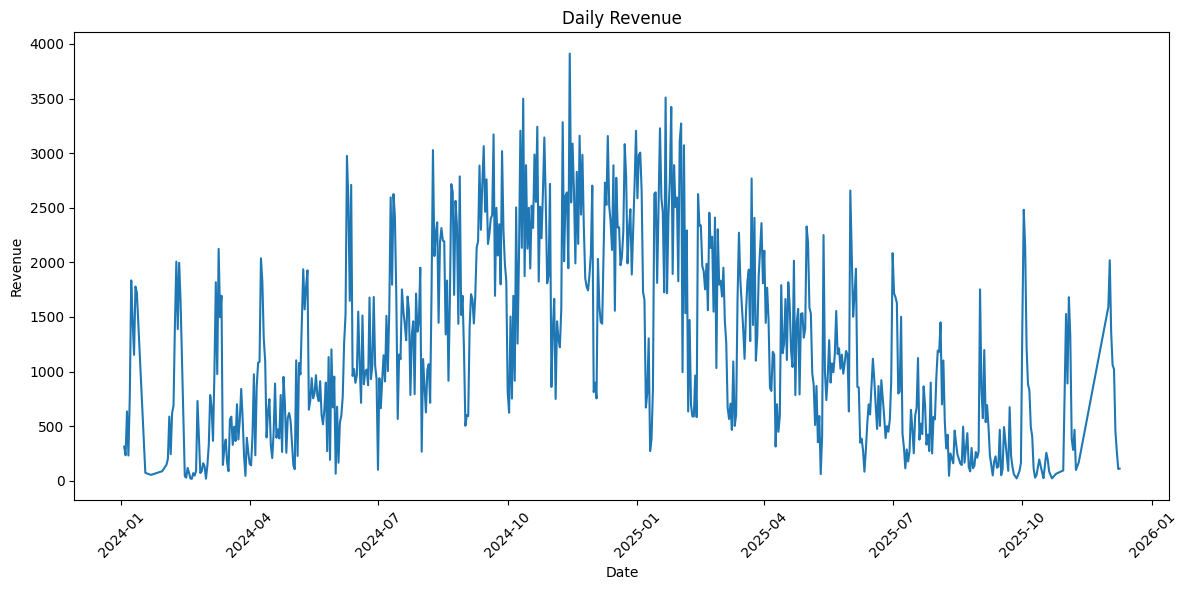

In [188]:
daily_revenue_df = (
    orders_df
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "daily_revenue"})
    .sort_values("date")
)

plt.figure(figsize=(12, 6))
plt.plot(daily_revenue_df["date"], daily_revenue_df["daily_revenue"])
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [190]:
daily_revenue_df.to_csv("daily_revenue_data_1.csv", index=False)